In [4]:
#importing all the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
orders = pd.read_csv("orders.csv")
order_items = pd.read_csv("order_items.csv")
order_item_refunds = pd.read_csv("order_item_refunds.csv")
products = pd.read_csv("products.csv")
website_sessions = pd.read_csv("website_sessions.csv")
website_pageviews = pd.read_csv("website_pageviews.csv")

In [6]:
print("Orders:", orders.shape)
print("Order Items:", order_items.shape)
print("Refunds:", order_item_refunds.shape)
print("Products:", products.shape)
print("Sessions:", website_sessions.shape)
print("Pageviews:", website_pageviews.shape)

Orders: (32313, 8)
Order Items: (40025, 7)
Refunds: (1731, 5)
Products: (4, 3)
Sessions: (472871, 9)
Pageviews: (1188124, 4)


In [7]:
#datasets overview
datasets = {
    "Orders": orders,
    "Order Items": order_items,
    "Refunds": order_item_refunds,
    "Products": products,
    "Website Sessions": website_sessions,
    "Website Pageviews": website_pageviews
}

for name, df in datasets.items():
    print(f"\n{name}")
    print("Shape:", df.shape)
    print("Columns:", list(df.columns))


Orders
Shape: (32313, 8)
Columns: ['order_id', 'created_at', 'website_session_id', 'user_id', 'primary_product_id', 'items_purchased', 'price_usd', 'cogs_usd']

Order Items
Shape: (40025, 7)
Columns: ['order_item_id', 'created_at', 'order_id', 'product_id', 'is_primary_item', 'price_usd', 'cogs_usd']

Refunds
Shape: (1731, 5)
Columns: ['order_item_refund_id', 'created_at', 'order_item_id', 'order_id', 'refund_amount_usd']

Products
Shape: (4, 3)
Columns: ['product_id', 'created_at', 'product_name']

Website Sessions
Shape: (472871, 9)
Columns: ['website_session_id', 'created_at', 'user_id', 'is_repeat_session', 'utm_source', 'utm_campaign', 'utm_content', 'device_type', 'http_referer']

Website Pageviews
Shape: (1188124, 4)
Columns: ['website_pageview_id', 'created_at', 'website_session_id', 'pageview_url']


In [8]:
#Checking Data Types & Missing Values
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    print(df.info())
    print("\nMissing Values:")
    print(df.isnull().sum())


Orders
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32313 entries, 0 to 32312
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   order_id            32313 non-null  int64  
 1   created_at          32313 non-null  object 
 2   website_session_id  32313 non-null  int64  
 3   user_id             32313 non-null  int64  
 4   primary_product_id  32313 non-null  int64  
 5   items_purchased     32313 non-null  int64  
 6   price_usd           32313 non-null  float64
 7   cogs_usd            32313 non-null  float64
dtypes: float64(2), int64(5), object(1)
memory usage: 2.0+ MB
None

Missing Values:
order_id              0
created_at            0
website_session_id    0
user_id               0
primary_product_id    0
items_purchased       0
price_usd             0
cogs_usd              0
dtype: int64

Order Items
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40025 entries, 0 to 40024
Data columns (to

In [9]:
# checking for duplicates 
for name, df in datasets.items():
    print(name, "duplicates:", df.duplicated().sum())

Orders duplicates: 0
Order Items duplicates: 0
Refunds duplicates: 0
Products duplicates: 0
Website Sessions duplicates: 0
Website Pageviews duplicates: 0


In [10]:
#checking invalid or negative values
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    numeric_cols = df.select_dtypes(include="number").columns

    for col in numeric_cols:
        negative_count = (df[col] < 0).sum()
        if negative_count > 0:
            print(f"{col}: {negative_count} negative values")


Orders

Order Items

Refunds

Products

Website Sessions

Website Pageviews


In [11]:
#converting created at columns to date time
date_cols = {
    "Orders": ["created_at"],
    "Order Items": ["created_at"],
    "Refunds": ["created_at"],
    "Products": ["created_at"],
    "Website Sessions": ["created_at"],
    "Website Pageviews": ["created_at"]
}

for name, cols in date_cols.items():
    df = datasets[name]

    for col in cols:
        df[col] = pd.to_datetime(df[col], errors="coerce")

print("Date conversion completed.")

Date conversion completed.


In [12]:
# checking the date range
for name, df in datasets.items():
    print(f"\n{name}")
    print("Start date:", df["created_at"].min())
    print("End date:", df["created_at"].max())


Orders
Start date: 2012-03-19 10:42:46
End date: 2015-03-19 05:38:31

Order Items
Start date: 2012-03-19 10:42:46
End date: 2015-03-19 05:38:31

Refunds
Start date: 2012-04-06 11:32:43
End date: 2015-04-01 18:11:08

Products
Start date: 2012-03-19 08:00:00
End date: 2014-02-05 10:00:00

Website Sessions
Start date: 2012-03-19 08:04:16
End date: 2015-03-19 07:59:08

Website Pageviews
Start date: 2012-03-19 08:04:16
End date: 2015-03-19 07:59:32


In [13]:
# checking for invalid ids
id_cols = {
    "Orders": ["order_id", "website_session_id", "user_id", "primary_product_id"],
    "Order Items": ["order_item_id", "order_id", "product_id"],
    "Refunds": ["order_item_refund_id", "order_item_id", "order_id"],
    "Products": ["product_id"],
    "Website Sessions": ["website_session_id", "user_id"],
    "Website Pageviews": ["website_pageview_id", "website_session_id"]
}

for name, cols in id_cols.items():
    df = datasets[name]

    print(f"\n{name}")
    for col in cols:
        print(f"{col}: {df[col].isna().sum()} missing")


Orders
order_id: 0 missing
website_session_id: 0 missing
user_id: 0 missing
primary_product_id: 0 missing

Order Items
order_item_id: 0 missing
order_id: 0 missing
product_id: 0 missing

Refunds
order_item_refund_id: 0 missing
order_item_id: 0 missing
order_id: 0 missing

Products
product_id: 0 missing

Website Sessions
website_session_id: 0 missing
user_id: 0 missing

Website Pageviews
website_pageview_id: 0 missing
website_session_id: 0 missing


In [14]:
# checking the main numeric columns
for name, df in datasets.items():
    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")
    print(df.describe())


Orders
           order_id                     created_at  website_session_id  \
count  32313.000000                          32313        32313.000000   
mean   16157.000000  2014-04-14 03:01:01.276823552       258292.288707   
min        1.000000            2012-03-19 10:42:46           20.000000   
25%     8079.000000            2013-10-30 14:30:35       144828.000000   
50%    16157.000000            2014-06-11 14:27:02       263554.000000   
75%    24235.000000            2014-11-28 10:53:48       374799.000000   
max    32313.000000            2015-03-19 05:38:31       472818.000000   
std     9328.103961                            NaN       132427.649842   

             user_id  primary_product_id  items_purchased     price_usd  \
count   32313.000000        32313.000000     32313.000000  32313.000000   
mean   215691.622629            1.392474         1.238666     59.991636   
min        13.000000            1.000000         1.000000     29.990000   
25%    124135.000000     

In [15]:
# creating useful date features
for name, df in datasets.items():
    df["year"] = df["created_at"].dt.year
    df["month"] = df["created_at"].dt.month
    df["day_of_week"] = df["created_at"].dt.day_name()

print("Date features created.")

Date features created.


In [16]:
# checking the main categorical columns
categorical_cols = {
    "Website Sessions": ["utm_source", "utm_campaign", "device_type", "is_repeat_session"],
    "Website Pageviews": ["pageview_url"],
    "Products": ["product_name"]
}

for name, cols in categorical_cols.items():
    df = datasets[name]

    print(f"\n{'='*50}")
    print(name)
    print(f"{'='*50}")

    for col in cols:
        print(f"\n{col}:")
        print(df[col].value_counts(dropna=False).head(15))


Website Sessions

utm_source:
utm_source
gsearch       316035
NaN            83328
bsearch        62823
socialbook     10685
Name: count, dtype: int64

utm_campaign:
utm_campaign
nonbrand            337615
NaN                  83328
brand                41243
desktop_targeted      5590
pilot                 5095
Name: count, dtype: int64

device_type:
device_type
desktop    327027
mobile     145844
Name: count, dtype: int64

is_repeat_session:
is_repeat_session
0    394318
1     78553
Name: count, dtype: int64

Website Pageviews

pageview_url:
pageview_url
/products                    261231
/the-original-mr-fuzzy       162525
/home                        137576
/lander-2                    131170
/cart                         94953
/lander-3                     79000
/lander-5                     68166
/shipping                     64484
/billing-2                    48441
/lander-1                     47574
/thank-you-for-your-order     32313
/the-forever-love-bear        26033
/the

In [ ]:
#Exploratory Data Analysis.

In [17]:
#Create the first EDA analysis: Monthly Revenue
monthly_revenue = (
    orders.groupby(orders["created_at"].dt.to_period("M"))["price_usd"]
    .sum()
    .reset_index()
)

monthly_revenue["created_at"] = monthly_revenue["created_at"].astype(str)

monthly_revenue

,created_at,price_usd
0,2012-03,2999.40
1,2012-04,4949.01
2,2012-05,5398.92
3,2012-06,6998.60
4,2012-07,8448.31
5,2012-08,11397.72
6,2012-09,14347.13
7,2012-10,18546.29
8,2012-11,30893.82
9,2012-12,25294.94


In [18]:
#Monthly Orders
monthly_orders = (
    orders.groupby(orders["created_at"].dt.to_period("M"))["order_id"]
    .nunique()
    .reset_index()
)

monthly_orders["created_at"] = monthly_orders["created_at"].astype(str)

monthly_orders

,created_at,order_id
0,2012-03,60
1,2012-04,99
2,2012-05,108
3,2012-06,140
4,2012-07,169
5,2012-08,228
6,2012-09,287
7,2012-10,371
8,2012-11,618
9,2012-12,506


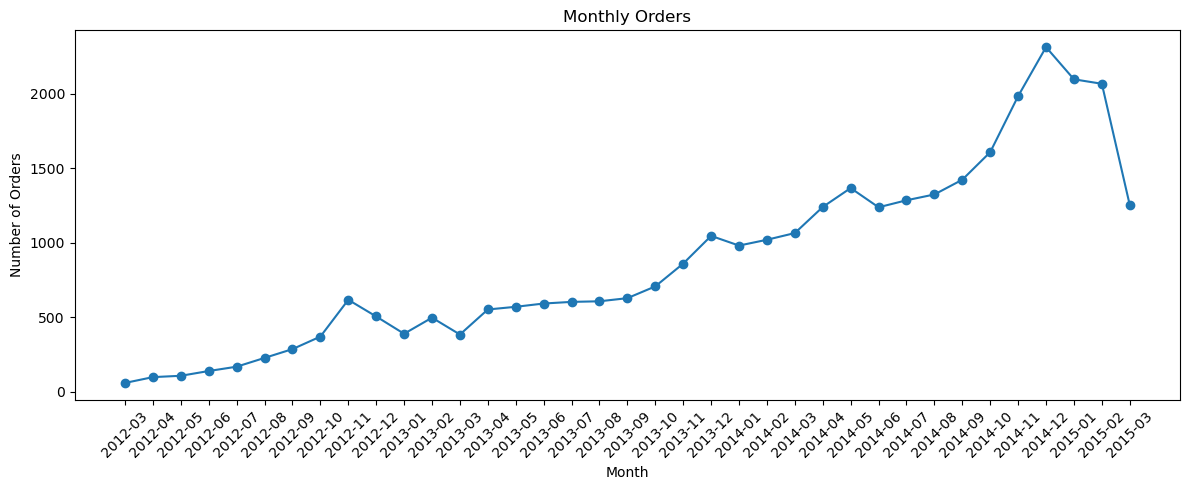

In [19]:
#Monthly Orders Visualization
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))
plt.plot(monthly_orders["created_at"], monthly_orders["order_id"], marker="o")
plt.title("Monthly Orders")
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

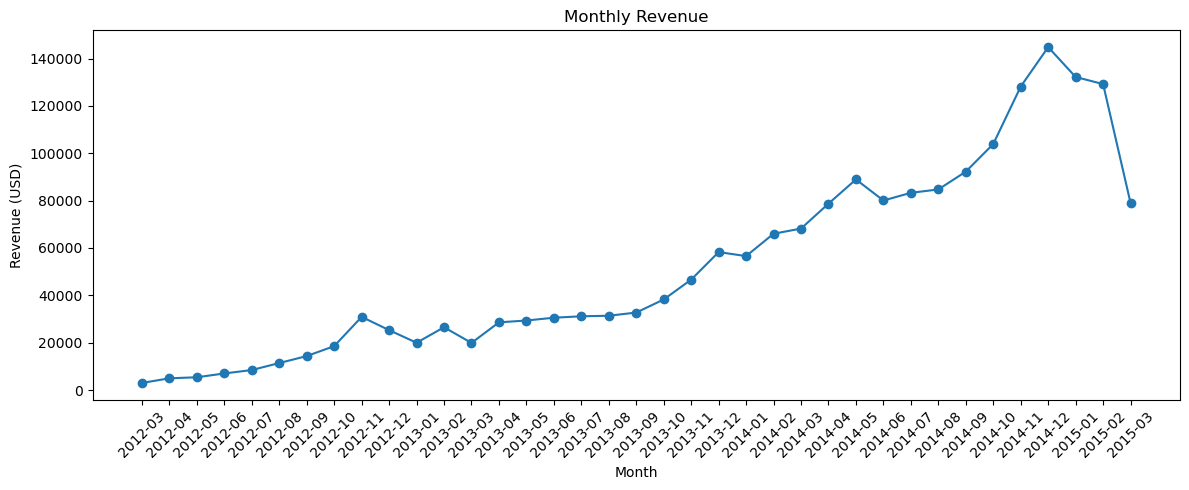

In [20]:
#Monthly Revenue Visualization
plt.figure(figsize=(12,5))
plt.plot(monthly_revenue["created_at"], monthly_revenue["price_usd"], marker="o")
plt.title("Monthly Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [21]:
#Revenue by Product
product_revenue = (
    orders.groupby("primary_product_id")["price_usd"]
    .sum()
    .sort_values(ascending=False)
)

product_revenue

primary_product_id
1    1419767.82
2     318109.18
3     180857.03
4      19775.72
Name: price_usd, dtype: float64

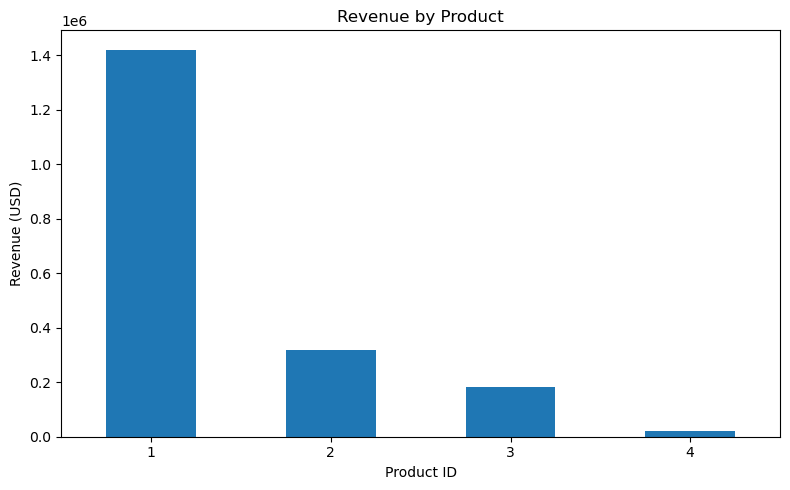

In [22]:
#Revenue by Product visualization
product_revenue.plot(kind="bar", figsize=(8,5))
plt.title("Revenue by Product")
plt.xlabel("Product ID")
plt.ylabel("Revenue (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [23]:
#Orders by Product
product_orders = (
    orders.groupby("primary_product_id")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

product_orders

primary_product_id
1    23861
2     4803
3     3068
4      581
Name: order_id, dtype: int64

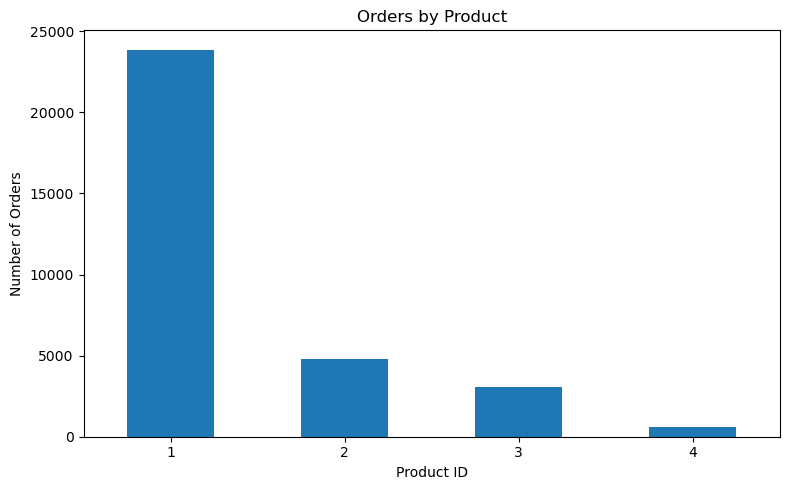

In [24]:
#Orders by Product visualization
product_orders.plot(kind="bar", figsize=(8,5))
plt.title("Orders by Product")
plt.xlabel("Product ID")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [25]:
#Sessions by Device
device_sessions = (
    website_sessions.groupby("device_type")["website_session_id"]
    .nunique()
    .sort_values(ascending=False)
)

device_sessions

device_type
desktop    327027
mobile     145844
Name: website_session_id, dtype: int64

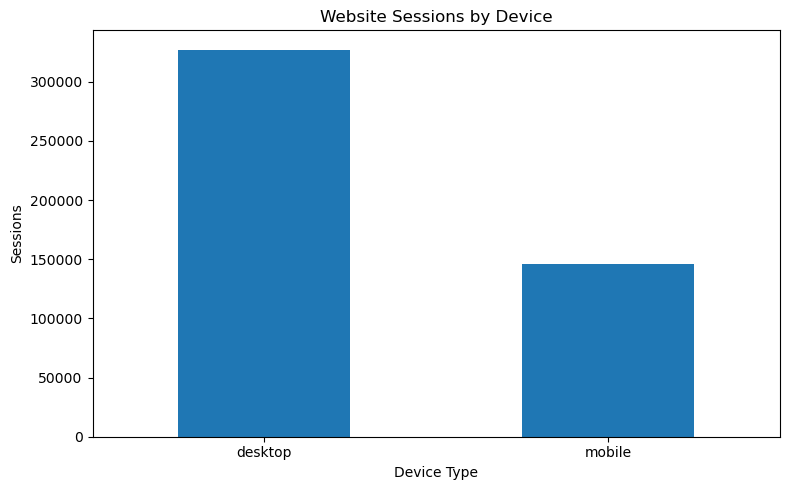

In [26]:
#Sessions by Device visualization
device_sessions.plot(kind="bar", figsize=(8,5))
plt.title("Website Sessions by Device")
plt.xlabel("Device Type")
plt.ylabel("Sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [27]:
#Sessions by Traffic Source
source_sessions = (
    website_sessions.groupby("utm_source")["website_session_id"]
    .nunique()
    .sort_values(ascending=False)
)

source_sessions


utm_source
gsearch       316035
bsearch        62823
socialbook     10685
Name: website_session_id, dtype: int64

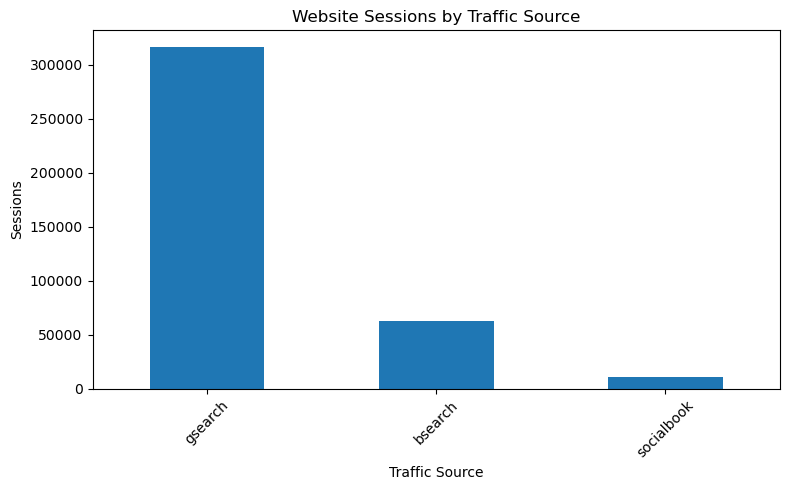

In [28]:
#Sessions by Traffic Source visualization
source_sessions.plot(kind="bar", figsize=(8,5))
plt.title("Website Sessions by Traffic Source")
plt.xlabel("Traffic Source")
plt.ylabel("Sessions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [29]:
#New vs Repeat Sessions
session_type = (
    website_sessions["is_repeat_session"]
    .value_counts()
)

session_type
    

is_repeat_session
0    394318
1     78553
Name: count, dtype: int64

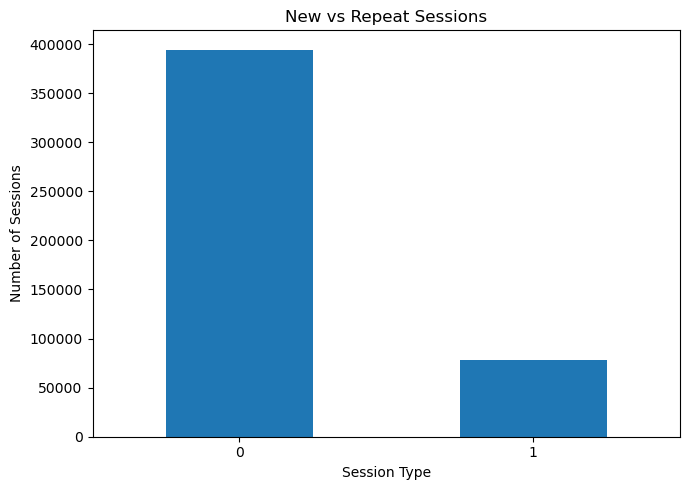

In [31]:
#New vs Repeat Sessions visualization
session_type.plot(kind="bar", figsize=(7,5))
plt.title("New vs Repeat Sessions")
plt.xlabel("Session Type")
plt.ylabel("Number of Sessions")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [33]:
#Marketing Source Conversion Rate
session_orders = orders.merge(
    website_sessions[["website_session_id", "utm_source"]],
    on="website_session_id",
    how="left"
)

In [34]:
source_orders = (
    session_orders.groupby("utm_source")["order_id"]
    .nunique()
)

source_conversion = (
    source_orders / source_sessions * 100
).sort_values(ascending=False)

source_conversion

utm_source
bsearch       7.193225
gsearch       6.750202
socialbook    3.210108
dtype: float64

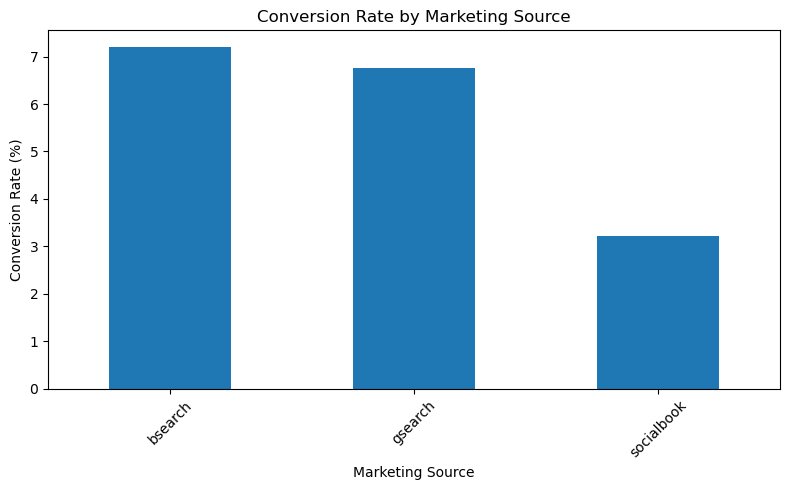

In [35]:
#Marketing Source Conversion Rate visualize
source_conversion.plot(kind="bar", figsize=(8,5))
plt.title("Conversion Rate by Marketing Source")
plt.xlabel("Marketing Source")
plt.ylabel("Conversion Rate (%)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [36]:
#Refund Analysis
refund_by_product = (
    order_item_refunds
    .merge(
        order_items[["order_item_id", "product_id"]],
        on="order_item_id",
        how="left"
    )
    .groupby("product_id")["refund_amount_usd"]
    .sum()
    .sort_values(ascending=False)
)

refund_by_product

product_id
1    61837.63
3    13842.99
2     7738.71
4     1919.36
Name: refund_amount_usd, dtype: float64

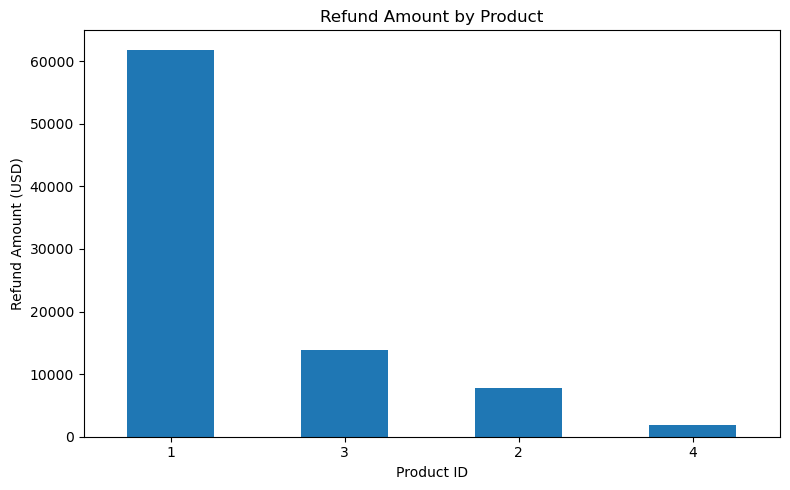

In [37]:
#Refund Analysis visualization
refund_by_product.plot(kind="bar", figsize=(8,5))
plt.title("Refund Amount by Product")
plt.xlabel("Product ID")
plt.ylabel("Refund Amount (USD)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [38]:
#Website Pageviews
pageviews_per_session = (
    website_pageviews.groupby("website_session_id")
    .size()
)

pageviews_per_session.describe()

count    472871.000000
mean          2.512575
std           1.816384
min           1.000000
25%           1.000000
50%           2.000000
75%           3.000000
max           7.000000
dtype: float64

In [39]:
#oreders by device 
orders_device = (
    session_orders.groupby("utm_source")["order_id"]
    .nunique()
)

orders_device


utm_source
bsearch        4519
gsearch       21333
socialbook      343
Name: order_id, dtype: int64

In [40]:
session_device_orders = orders.merge(
    website_sessions[["website_session_id", "device_type"]],
    on="website_session_id",
    how="left"
)

orders_by_device = (
    session_device_orders.groupby("device_type")["order_id"]
    .nunique()
    .sort_values(ascending=False)
)

orders_by_device

device_type
desktop    27805
mobile      4508
Name: order_id, dtype: int64

In [41]:
# average order value
total_revenue = orders["price_usd"].sum()
total_orders = orders["order_id"].nunique()

aov = total_revenue / total_orders

print("Average Order Value:", round(aov, 2))

Average Order Value: 59.99


In [42]:
# total refund rate 
total_refunds = order_item_refunds["refund_amount_usd"].sum()

refund_rate = total_refunds / total_revenue * 100

print("Refund Rate:", round(refund_rate, 2), "%")

Refund Rate: 4.4 %


In [43]:
# top customer by revenue
customer_revenue = (
    orders.groupby("user_id")["price_usd"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

customer_revenue

user_id
341972    251.94
324814    245.95
172266    237.95
275098    235.95
281298    219.96
142410    219.96
317773    215.96
336150    209.95
218722    205.96
307597    205.96
Name: price_usd, dtype: float64

In [44]:
# new vs repeat customers
customer_orders = (
    orders.groupby("user_id")["order_id"]
    .nunique()
)

repeat_customers = (customer_orders > 1).sum()
total_customers = customer_orders.nunique()
new_customers = total_customers - repeat_customers

print("Total Customers:", total_customers)
print("New Customers:", new_customers)
print("Repeat Customers:", repeat_customers)
print(
    "Repeat Customer %:",
    round(repeat_customers / total_customers * 100, 2),
    "%"
)

Total Customers: 3
New Customers: -588
Repeat Customers: 591
Repeat Customer %: 19700.0 %
